# Comparison: Data vs Simulation vs Smeared Simulation

This notebook compares the experimental data with GEANT4 simulation (original and smeared).

**Note on weighting methodology:**
- **Data histograms:** use `pi0_weight * scale * is_exclusive` for all variables (matches nps_sim_smearing.C)
- **Simulation histograms:** use **unweighted events** (weight=1.0 per event), then the entire histogram is scaled to match the data integral
- This matches the methodology used in `nps_sim_smearing.C` which generates `chi2_scans.pdf`


In [134]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## Load Data Files

In [135]:
# File paths
data_file = "../output/plots/x60_4b/combined_branches_LH2.root"  # Experimental data
sim_file = "../output/plots/x60_4b/simc_pi0_analysis_output.root"  # Unsmeared simulation
sim_smeared_file = "../output/plots/x60_4b/simc_pi0_analysis_output_smeared.root"  # Smeared simulation

# Load trees
print("Loading data...")
data_tree = uproot.open(data_file)["physics"]
print(f"Data entries: {data_tree.num_entries}")

print("\nLoading simulation...")
sim_tree = uproot.open(sim_file)["simulation"]
print(f"Simulation entries: {sim_tree.num_entries}")

print("\nLoading smeared simulation...")
sim_smeared_tree = uproot.open(sim_smeared_file)["simulation"]
print(f"Smeared simulation entries: {sim_smeared_tree.num_entries}")

Loading data...
Data entries: 860040

Loading simulation...
Simulation entries: 500000

Loading smeared simulation...
Smeared simulation entries: 113423


## Extract Variables

In [136]:
# Branch name mapping: data -> simulation
# Data uses different branch names
data_branch_map = {
    'mpi0': 'mpi0_all',
    'mmiss': 'mmiss_all',  # Use corrected missing mass
    'Q2': 'Q2',
    'W': 'W',
    'xB': 'xB',
    'z': 'z',
    'theta': 'theta',
    'weight': 'pi0_weight',
    'scale': 'scale',
    'nclust': 'nclust_selected',
    'is_exclusive': 'is_exclusive',
    # Cluster position and energy for both photons (data only)
    'cluster_x_1': 'cluster_x_1',
    'cluster_y_1': 'cluster_y_1',
    'cluster_e_1': 'cluster_e_1',
    'cluster_x_2': 'cluster_x_2',
    'cluster_y_2': 'cluster_y_2',
    'cluster_e_2': 'cluster_e_2'
}

# Variables to compare (using simulation names as standard)
variables = ['mpi0', 'mmiss', 'Q2', 'W', 'xB', 'z', 'theta', 
             'weight', 'scale', 'nclust', 'is_exclusive']

# Data-only cluster variables
data_cluster_vars = ['cluster_x_1', 'cluster_y_1', 'cluster_e_1',
                     'cluster_x_2', 'cluster_y_2', 'cluster_e_2']

# Load data (with branch name mapping)
print("Extracting data variables...")
data = {}
for var in variables + data_cluster_vars:
    data_branch = data_branch_map.get(var, var)
    if data_branch in data_tree.keys():
        data[var] = data_tree[data_branch].array(library="np")
    else:
        print(f"Warning: {data_branch} not found in data")
        data[var] = np.array([])

# Load simulation (note: sim uses different HMS branch names)
# Note: simulation does NOT have is_exclusive branch
print("Extracting simulation variables...")
sim = {}
sim_branch_map = {
    'theta': 'theta_e',
    'weight': 'full_weight'
}
sim_variables = [v for v in variables if v != 'is_exclusive']  # Exclude is_exclusive
for var in sim_variables:
    sim_branch = sim_branch_map.get(var, var)
    if sim_branch in sim_tree.keys():
        sim[var] = sim_tree[sim_branch].array(library="np")
    else:
        print(f"Warning: {sim_branch} not found in simulation")
        sim[var] = np.array([])

# Load simulation cluster arrays (these contain all clusters, not individual ones)
print("Extracting simulation cluster variables...")
if 'clust_X' in sim_tree.keys():
    sim['clust_X'] = sim_tree['clust_X'].array(library="np")
if 'clust_Y' in sim_tree.keys():
    sim['clust_Y'] = sim_tree['clust_Y'].array(library="np")
if 'clust_E' in sim_tree.keys():
    sim['clust_E'] = sim_tree['clust_E'].array(library="np")

# Load smeared simulation (same branch names as unsmeared sim)
print("Extracting smeared simulation variables...")
sim_smeared = {}
for var in sim_variables:
    sim_branch = sim_branch_map.get(var, var)
    if sim_branch in sim_smeared_tree.keys():
        sim_smeared[var] = sim_smeared_tree[sim_branch].array(library="np")
    else:
        print(f"Warning: {sim_branch} not found in smeared simulation")
        sim_smeared[var] = np.array([])

# Load smeared simulation cluster arrays
print("Extracting smeared simulation cluster variables...")
if 'clust_X' in sim_smeared_tree.keys():
    sim_smeared['clust_X'] = sim_smeared_tree['clust_X'].array(library="np")
if 'clust_Y' in sim_smeared_tree.keys():
    sim_smeared['clust_Y'] = sim_smeared_tree['clust_Y'].array(library="np")
if 'clust_E' in sim_smeared_tree.keys():
    sim_smeared['clust_E'] = sim_smeared_tree['clust_E'].array(library="np")

print("\nData extraction complete!")

Extracting data variables...
Extracting simulation variables...
Extracting simulation cluster variables...
Extracting smeared simulation variables...
Extracting smeared simulation cluster variables...

Data extraction complete!


## Apply Cuts and Calculate Weights

In [137]:
# Apply nclust == 2 cut for data
data_cut = data['nclust'] == 2 if len(data['nclust']) > 0 else np.ones(len(data['mpi0']), dtype=bool)

# Apply nclust == 2 cut for simulation
sim_cut = sim['nclust'] == 2 if len(sim['nclust']) > 0 else np.ones(len(sim['mpi0']), dtype=bool)

# Apply nclust == 2 cut for smeared simulation
sim_smeared_cut = sim_smeared['nclust'] == 2 if len(sim_smeared['nclust']) > 0 else np.ones(len(sim_smeared['mpi0']), dtype=bool)

print(f"Data events after nclust==2 cut: {np.sum(data_cut)}")
print(f"Simulation events after nclust==2 cut: {np.sum(sim_cut)}")
print(f"Smeared simulation events after nclust==2 cut: {np.sum(sim_smeared_cut)}")

# Calculate normalization factors
# For data, use pi0_weight * scale * is_exclusive (matches nps_sim_smearing.C)
base_weight = data['weight'][data_cut] if len(data['weight']) > 0 else np.ones(np.sum(data_cut))
scale_factor = data['scale'][data_cut] if len(data['scale']) > 0 else np.ones(np.sum(data_cut))
is_excl = data['is_exclusive'][data_cut] if len(data['is_exclusive']) > 0 else np.ones(np.sum(data_cut))
data_weights = base_weight * scale_factor * is_excl
data_total = np.sum(data_weights)

# For simulation: Use unweighted counts (weight=1.0 per event) to match chi2_scans.pdf methodology
# Simulation histograms will be scaled by the ratio of integrals after filling
sim_total_unweighted = np.sum(sim_cut)  # Count of events
sim_smeared_total_unweighted = np.sum(sim_smeared_cut)  # Count of events

print(f"\nData total (weighted): {data_total:.2f}")
print(f"Simulation total (event count): {sim_total_unweighted}")
print(f"Smeared simulation total (event count): {sim_smeared_total_unweighted}")

print(f"\nNote: Simulation uses weight=1.0 per event, then histogram scaling to match chi2_scans.pdf methodology")
print(f"Note: Data weighting = pi0_weight * scale * is_exclusive (matches nps_sim_smearing.C)")

Data events after nclust==2 cut: 800502
Simulation events after nclust==2 cut: 113423
Smeared simulation events after nclust==2 cut: 113423

Data total (weighted): 18743.58
Simulation total (event count): 113423
Smeared simulation total (event count): 113423

Note: Simulation uses weight=1.0 per event, then histogram scaling to match chi2_scans.pdf methodology
Note: Data weighting = pi0_weight * scale * is_exclusive (matches nps_sim_smearing.C)


## Comparison Function

In [138]:
def plot_comparison(var_name, bins=50, range_vals=None, xlabel=None, title=None, log_scale=False):
    """
    Plot comparison of data, simulation, and smeared simulation
    Note: Uses unweighted simulation (weight=1.0 per event) to match chi2_scans.pdf methodology
    Note: Data uses pi0_weight * scale * is_exclusive for all variables (matches nps_sim_smearing.C)
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), 
                                    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})
    
    # Get data for this variable
    data_vals = data[var_name][data_cut]
    sim_vals = sim[var_name][sim_cut]
    sim_smeared_vals = sim_smeared[var_name][sim_smeared_cut]
    
    # Get weights - use pi0_weight * scale * is_exclusive for all data histograms
    base_weight = data['weight'][data_cut] if len(data['weight']) > 0 else np.ones(np.sum(data_cut))
    scale_factor = data['scale'][data_cut] if len(data['scale']) > 0 else np.ones(np.sum(data_cut))
    is_excl = data['is_exclusive'][data_cut] if len(data['is_exclusive']) > 0 else np.ones(np.sum(data_cut))
    data_weights_var = base_weight * scale_factor * is_excl
    
    # Simulation uses weight=1.0 per event (matching chi2_scans.pdf methodology)
    sim_weights = np.ones(len(sim_vals))
    sim_smeared_weights = np.ones(len(sim_smeared_vals))
    
    # Determine range if not provided
    if range_vals is None:
        # Use data range, filter out sentinel values
        valid_data = data_vals[data_vals > -900]
        if len(valid_data) > 0:
            p1, p99 = np.percentile(valid_data, [1, 99])
            range_vals = (p1, p99)
        else:
            range_vals = (np.min(data_vals), np.max(data_vals))
    
    # Main plot
    # Data histogram
    data_counts, bin_edges, _ = ax1.hist(data_vals, bins=bins, range=range_vals, 
                                          weights=data_weights_var,
                                          histtype='step', color='black', linewidth=2, 
                                          label='Data', density=False)
    
    # Simulation histogram (unsmeared) - unweighted, then scaled to match data integral
    sim_counts, _, _ = ax1.hist(sim_vals, bins=bin_edges, weights=sim_weights,
                                 histtype='step', color='blue', linewidth=2, 
                                 label='Simulation (unsmeared)', density=False, linestyle='--')
    
    # Smeared simulation histogram - unweighted, then scaled to match data integral
    sim_smeared_counts, _, _ = ax1.hist(sim_smeared_vals, bins=bin_edges, weights=sim_smeared_weights,
                                         histtype='step', color='red', linewidth=2, 
                                         label='Simulation (smeared)', density=False)
    
    # Scale simulation histograms to match data integral (same as chi2_scans.pdf)
    data_integral = np.sum(data_counts)
    sim_integral = np.sum(sim_counts)
    sim_smeared_integral = np.sum(sim_smeared_counts)
    
    if sim_integral > 0:
        sim_counts = sim_counts * (data_integral / sim_integral)
    if sim_smeared_integral > 0:
        sim_smeared_counts = sim_smeared_counts * (data_integral / sim_smeared_integral)
    
    # Clear and redraw with scaled histograms
    ax1.clear()
    ax1.stairs(data_counts, bin_edges, color='black', linewidth=2, label='Data')
    ax1.stairs(sim_counts, bin_edges, color='blue', linewidth=2, label='Simulation (unsmeared)', linestyle='--')
    ax1.stairs(sim_smeared_counts, bin_edges, color='red', linewidth=2, label='Simulation (smeared)')
    
    ax1.set_ylabel('Counts', fontsize=14)
    ax1.legend(fontsize=12, loc='best')
    if title:
        ax1.set_title(title, fontsize=16)
    if log_scale:
        ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(labelbottom=False)
    
    # Ratio plot
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Calculate ratios (avoid division by zero)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_sim = np.where(data_counts > 0, sim_counts / data_counts, np.nan)
        ratio_smeared = np.where(data_counts > 0, sim_smeared_counts / data_counts, np.nan)
    
    # Plot ratios
    ax2.plot(bin_centers, ratio_sim, 'o-', color='blue', label='Unsmeared / Data', markersize=4)
    ax2.plot(bin_centers, ratio_smeared, 's-', color='red', label='Smeared / Data', markersize=4)
    ax2.axhline(y=1, color='black', linestyle='--', linewidth=1)
    ax2.set_xlabel(xlabel if xlabel else var_name, fontsize=14)
    ax2.set_ylabel('Sim / Data', fontsize=14)
    ax2.set_ylim(0.5, 1.5)
    ax2.legend(fontsize=10, loc='best')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(range_vals)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{var_name} Statistics:")
    print(f"Data:             mean={np.mean(data_vals):.4f}, std={np.std(data_vals):.4f}")
    print(f"Sim (unsmeared):  mean={np.mean(sim_vals):.4f}, std={np.std(sim_vals):.4f}")
    print(f"Sim (smeared):    mean={np.mean(sim_smeared_vals):.4f}, std={np.std(sim_smeared_vals):.4f}")


## Pi0 Invariant Mass Comparison

/scratch/singhav/ipykernel_1191167/583236462.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


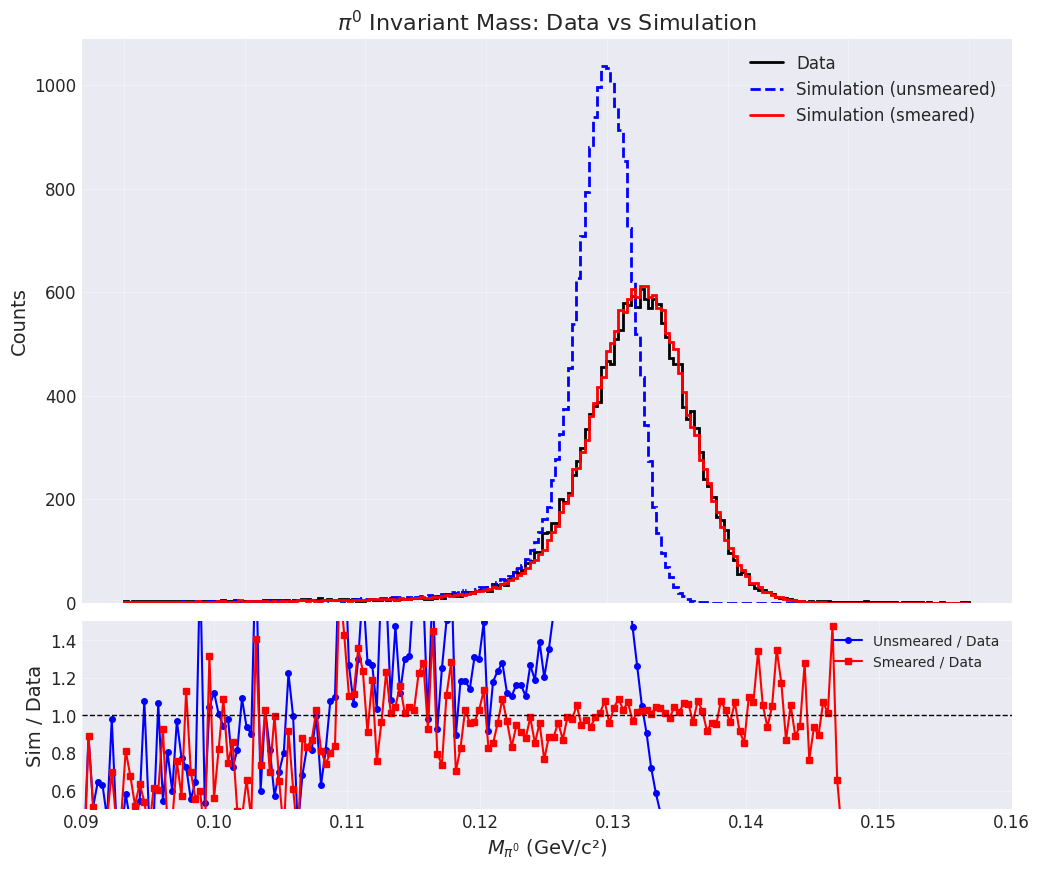


mpi0 Statistics:
Data:             mean=0.1140, std=0.0526
Sim (unsmeared):  mean=0.1287, std=0.0052
Sim (smeared):    mean=0.1318, std=0.0062


In [139]:
plot_comparison('mpi0', bins=200, range_vals=(0.09, 0.16), 
                xlabel=r'$M_{\pi^0}$ (GeV/c²)', 
                title=r'$\pi^0$ Invariant Mass: Data vs Simulation')

## Missing Mass Comparison

/scratch/singhav/ipykernel_1191167/583236462.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


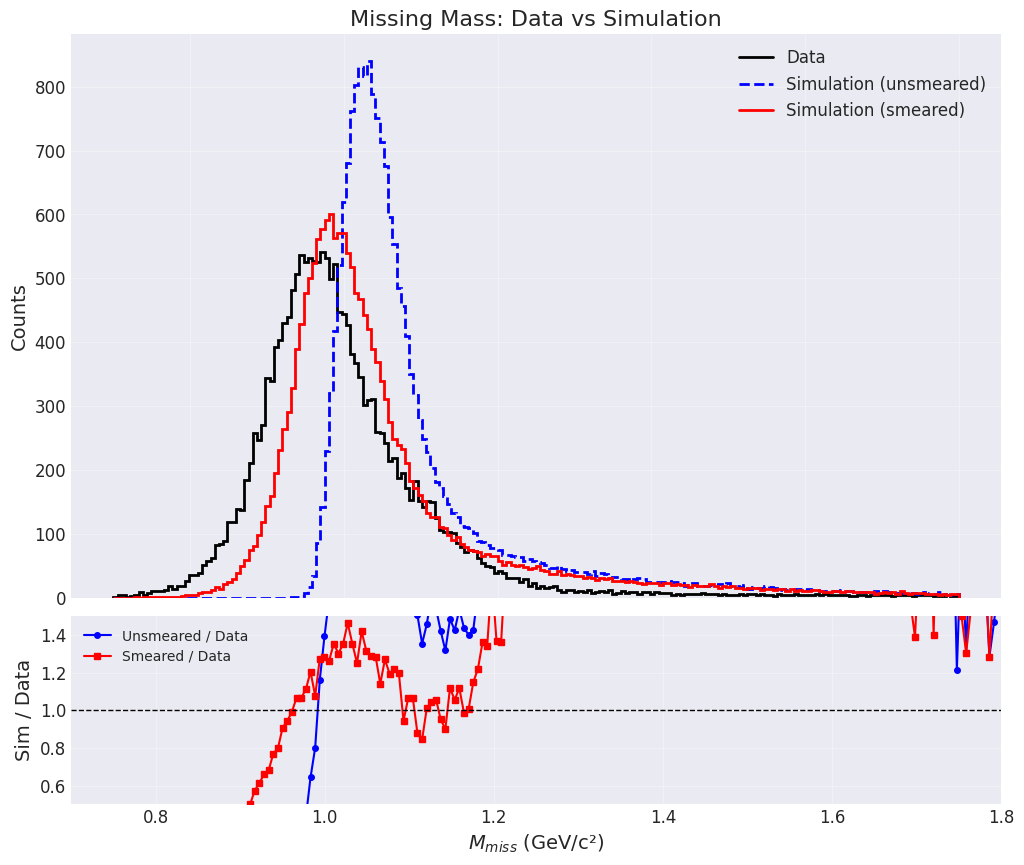


mmiss Statistics:
Data:             mean=1.6265, std=0.3840
Sim (unsmeared):  mean=1.1051, std=0.1577
Sim (smeared):    mean=1.0588, std=0.1694


In [140]:
plot_comparison('mmiss', bins=200, range_vals=(0.7, 1.8), 
                xlabel=r'$M_{miss}$ (GeV/c²)', 
                title='Missing Mass: Data vs Simulation')

## Q² Comparison

/scratch/singhav/ipykernel_1191167/583236462.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


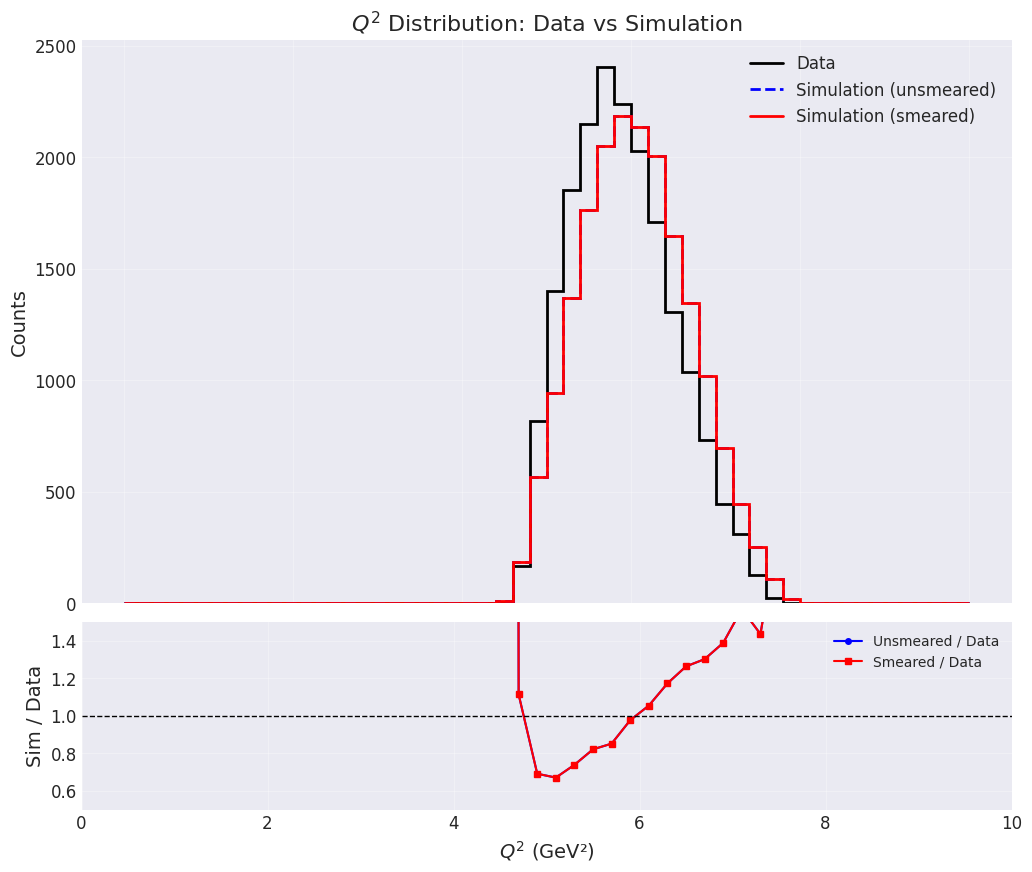


Q2 Statistics:
Data:             mean=5.7143, std=0.5703
Sim (unsmeared):  mean=6.0559, std=0.6378
Sim (smeared):    mean=6.0559, std=0.6378


In [141]:
plot_comparison('Q2', bins=50, range_vals=(0, 10), 
                xlabel=r'$Q^2$ (GeV²)', 
                title=r'$Q^2$ Distribution: Data vs Simulation')

## W Comparison

/scratch/singhav/ipykernel_1191167/583236462.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


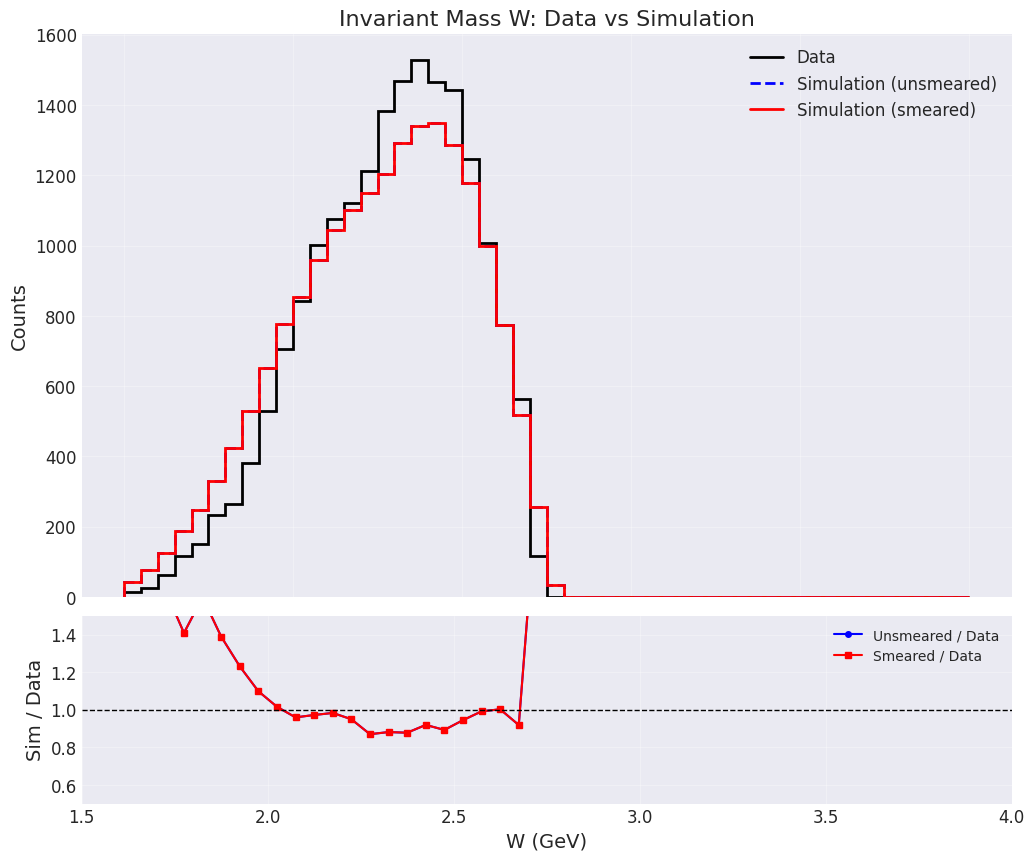


W Statistics:
Data:             mean=2.3674, std=0.2215
Sim (unsmeared):  mean=2.2572, std=0.2631
Sim (smeared):    mean=2.2572, std=0.2631


In [142]:
plot_comparison('W', bins=50, range_vals=(1.5, 4.0), 
                xlabel='W (GeV)', 
                title='Invariant Mass W: Data vs Simulation')

## Bjorken x Comparison

/scratch/singhav/ipykernel_1191167/583236462.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


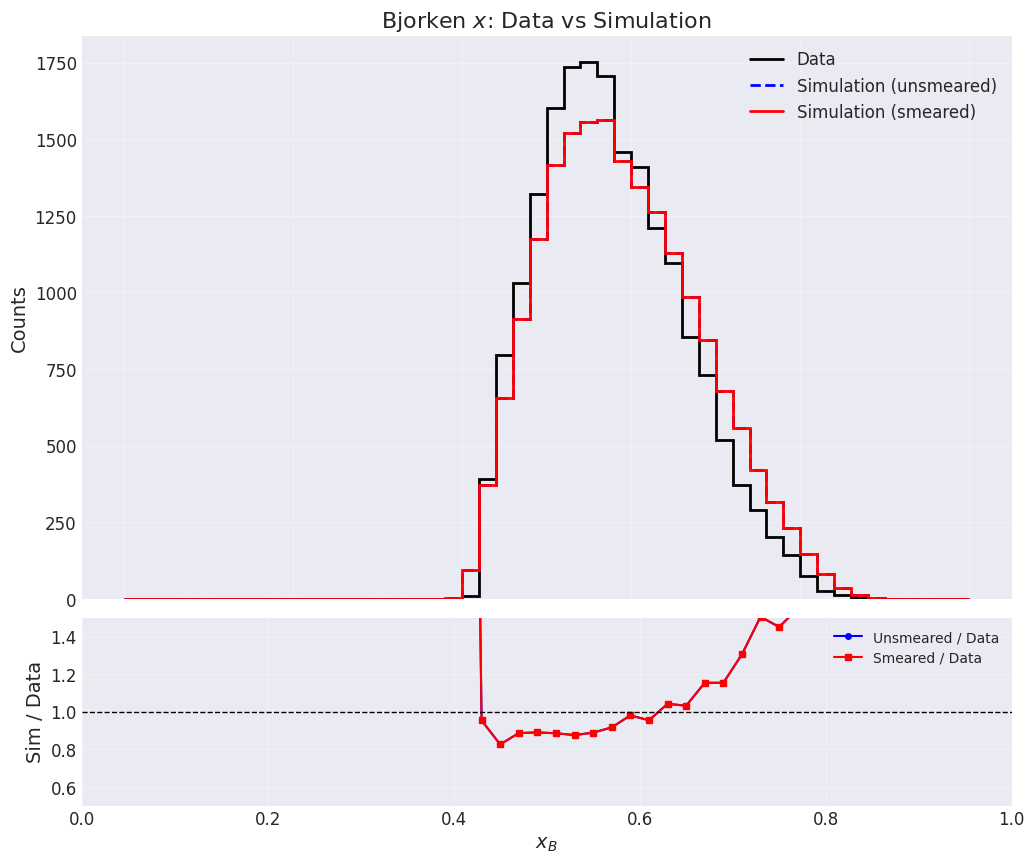


xB Statistics:
Data:             mean=0.5483, std=0.0775
Sim (unsmeared):  mean=0.5905, std=0.0910
Sim (smeared):    mean=0.5905, std=0.0910


In [143]:
plot_comparison('xB', bins=50, range_vals=(0.0, 1.0), 
                xlabel=r'$x_B$', 
                title=r'Bjorken $x$: Data vs Simulation')

## z (Energy Fraction) Comparison

/scratch/singhav/ipykernel_1191167/583236462.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


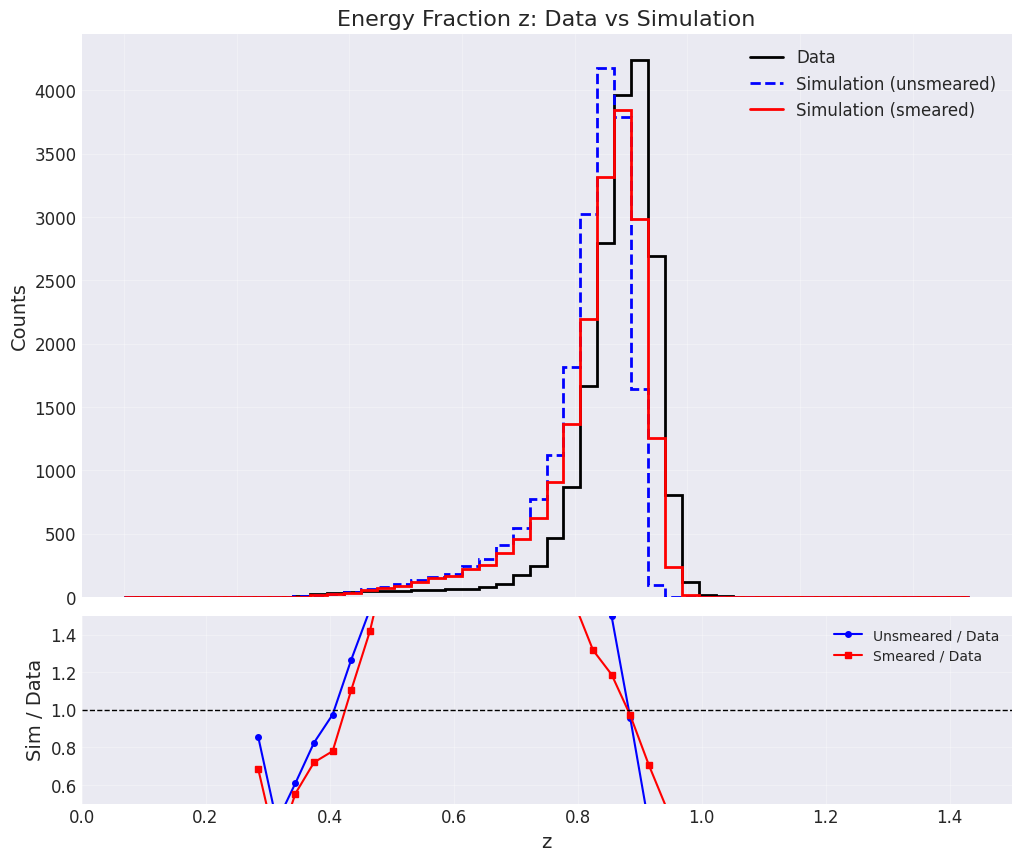


z Statistics:
Data:             mean=0.5535, std=0.1903
Sim (unsmeared):  mean=0.8162, std=0.0928
Sim (smeared):    mean=0.8363, std=0.0968


In [144]:
plot_comparison('z', bins=50, range_vals=(0.0, 1.5), 
                xlabel='z', 
                title='Energy Fraction z: Data vs Simulation')

## 2D Comparison: mpi0 vs mmiss

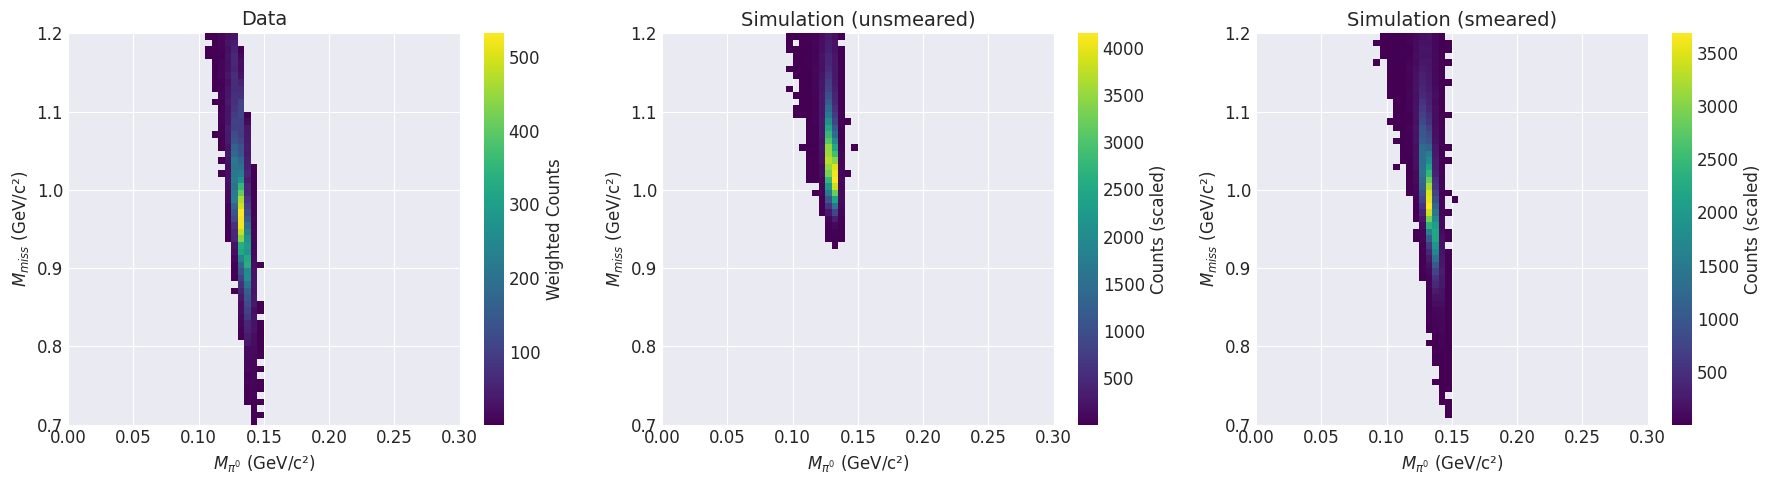

In [145]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Data (uses pi0_weight * is_exclusive)
# Note: For this 2D plot of mpi0 vs mmiss, we use the combined weight
# since mmiss requires exclusive event selection
base_weight = data['weight'][data_cut] if len(data['weight']) > 0 else np.ones(np.sum(data_cut))
is_excl = data['is_exclusive'][data_cut] if len(data['is_exclusive']) > 0 else np.ones(np.sum(data_cut))
data_weights_2d = base_weight * is_excl

h1 = axes[0].hist2d(data['mpi0'][data_cut], data['mmiss'][data_cut], 
                     bins=[60, 60], range=[[0.0, 0.3], [0.7, 1.2]], 
                     weights=data_weights_2d,
                     cmap='viridis', cmin=1)
axes[0].set_xlabel(r'$M_{\pi^0}$ (GeV/c²)', fontsize=12)
axes[0].set_ylabel(r'$M_{miss}$ (GeV/c²)', fontsize=12)
axes[0].set_title('Data', fontsize=14)
plt.colorbar(h1[3], ax=axes[0], label='Weighted Counts')

# Simulation (unsmeared) - unweighted (weight=1.0 per event), then scaled
sim_weights_2d = np.ones(np.sum(sim_cut))
h2 = axes[1].hist2d(sim['mpi0'][sim_cut], sim['mmiss'][sim_cut], 
                     bins=[60, 60], range=[[0.0, 0.3], [0.7, 1.2]], 
                     weights=sim_weights_2d, cmap='viridis', cmin=1)
# Scale to match data integral
data_integral_2d = np.sum(data_weights_2d)
sim_integral_2d = np.sum(sim_weights_2d)
if sim_integral_2d > 0:
    h2[0][:] = h2[0] * (data_integral_2d / sim_integral_2d)
axes[1].set_xlabel(r'$M_{\pi^0}$ (GeV/c²)', fontsize=12)
axes[1].set_ylabel(r'$M_{miss}$ (GeV/c²)', fontsize=12)
axes[1].set_title('Simulation (unsmeared)', fontsize=14)
plt.colorbar(h2[3], ax=axes[1], label='Counts (scaled)')

# Simulation (smeared) - unweighted (weight=1.0 per event), then scaled
sim_smeared_weights_2d = np.ones(np.sum(sim_smeared_cut))
h3 = axes[2].hist2d(sim_smeared['mpi0'][sim_smeared_cut], sim_smeared['mmiss'][sim_smeared_cut], 
                     bins=[60, 60], range=[[0.0, 0.3], [0.7, 1.2]], 
                     weights=sim_smeared_weights_2d, cmap='viridis', cmin=1)
# Scale to match data integral
sim_smeared_integral_2d = np.sum(sim_smeared_weights_2d)
if sim_smeared_integral_2d > 0:
    h3[0][:] = h3[0] * (data_integral_2d / sim_smeared_integral_2d)
axes[2].set_xlabel(r'$M_{\pi^0}$ (GeV/c²)', fontsize=12)
axes[2].set_ylabel(r'$M_{miss}$ (GeV/c²)', fontsize=12)
axes[2].set_title('Simulation (smeared)', fontsize=14)
plt.colorbar(h3[3], ax=axes[2], label='Counts (scaled)')

plt.tight_layout()
plt.show()


## Resolution Effects: Smeared vs Unsmeared Simulation

In [146]:
def plot_resolution_effect(var_name, bins=50, range_vals=None, xlabel=None):
    """
    Plot the difference between smeared and unsmeared simulation to visualize resolution effects
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    sim_vals = sim[var_name][sim_cut]
    sim_smeared_vals = sim_smeared[var_name][sim_smeared_cut]
    
    sim_weights = sim['weight'][sim_cut] if len(sim['weight']) > 0 else np.ones(len(sim_vals))
    sim_smeared_weights = sim_smeared['weight'][sim_smeared_cut] if len(sim_smeared['weight']) > 0 else np.ones(len(sim_smeared_vals))
    
    if range_vals is None:
        valid = sim_vals[sim_vals > -900]
        if len(valid) > 0:
            p1, p99 = np.percentile(valid, [1, 99])
            range_vals = (p1, p99)
    
    ax.hist(sim_vals, bins=bins, range=range_vals, weights=sim_weights,
            histtype='step', color='blue', linewidth=2, label='Unsmeared', density=True)
    ax.hist(sim_smeared_vals, bins=bins, range=range_vals, weights=sim_smeared_weights,
            histtype='step', color='red', linewidth=2, label='Smeared', density=True)
    
    ax.set_xlabel(xlabel if xlabel else var_name, fontsize=14)
    ax.set_ylabel('Normalized Counts', fontsize=14)
    ax.set_title(f'Resolution Effect on {var_name}', fontsize=16)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate resolution
    sigma_unsmeared = np.std(sim_vals)
    sigma_smeared = np.std(sim_smeared_vals)
    print(f"\n{var_name} Resolution:")
    print(f"σ (unsmeared): {sigma_unsmeared:.4f}")
    print(f"σ (smeared):   {sigma_smeared:.4f}")
    print(f"Additional smearing: {np.sqrt(max(0, sigma_smeared**2 - sigma_unsmeared**2)):.4f}")


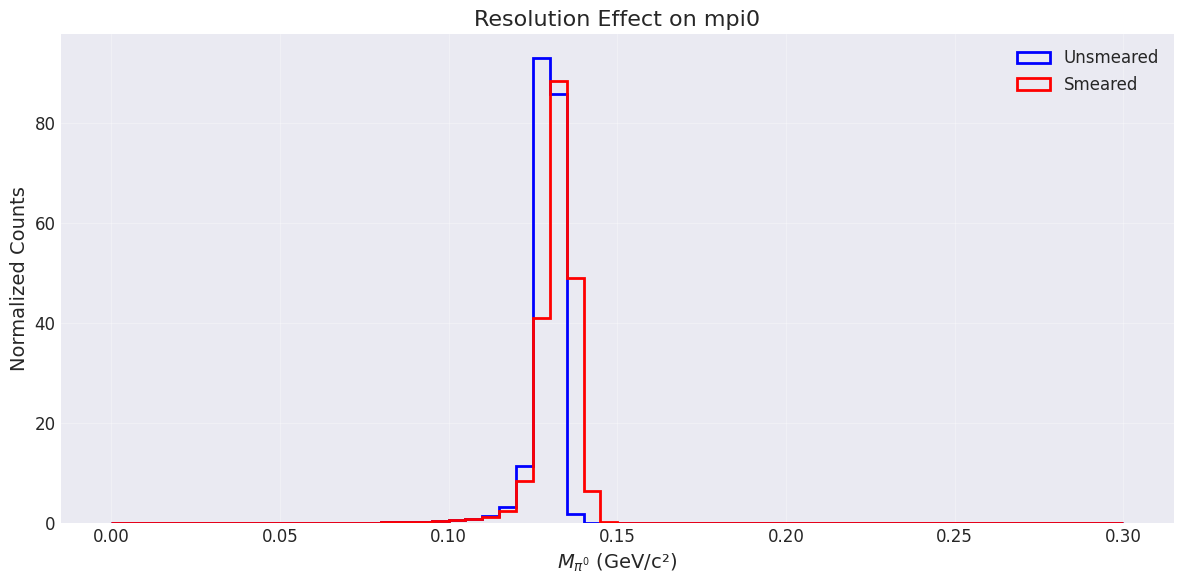


mpi0 Resolution:
σ (unsmeared): 0.0052
σ (smeared):   0.0062
Additional smearing: 0.0034


In [147]:
plot_resolution_effect('mpi0', bins=60, range_vals=(0.0, 0.3), xlabel=r'$M_{\pi^0}$ (GeV/c²)')


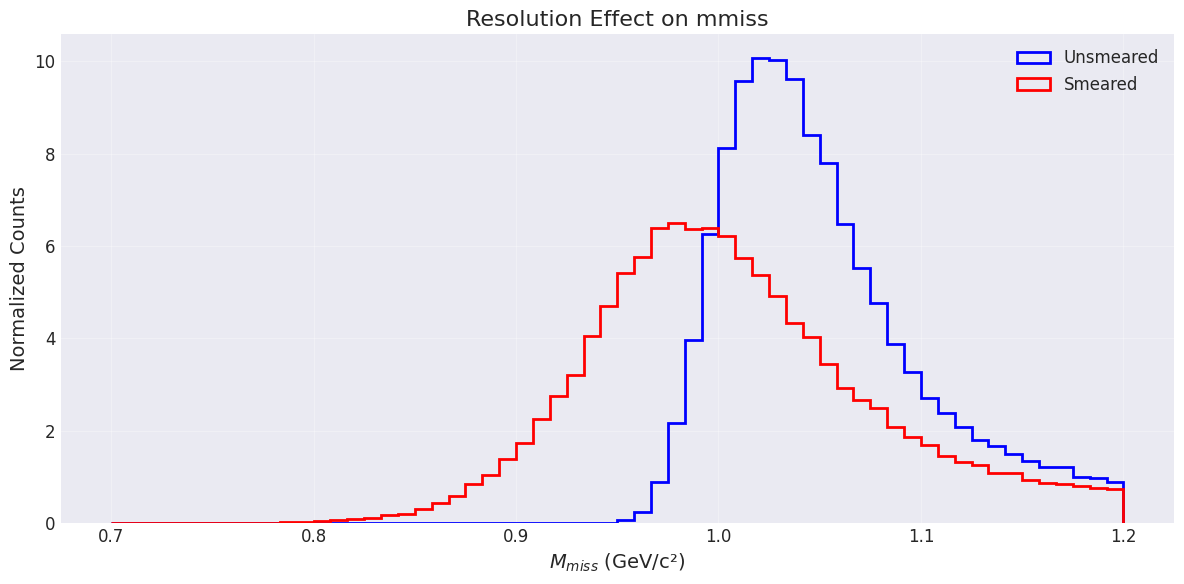


mmiss Resolution:
σ (unsmeared): 0.1577
σ (smeared):   0.1694
Additional smearing: 0.0621


In [148]:
plot_resolution_effect('mmiss', bins=60, range_vals=(0.7, 1.2), xlabel=r'$M_{miss}$ (GeV/c²)')


## Cluster Energy Distribution on Calorimeter Face

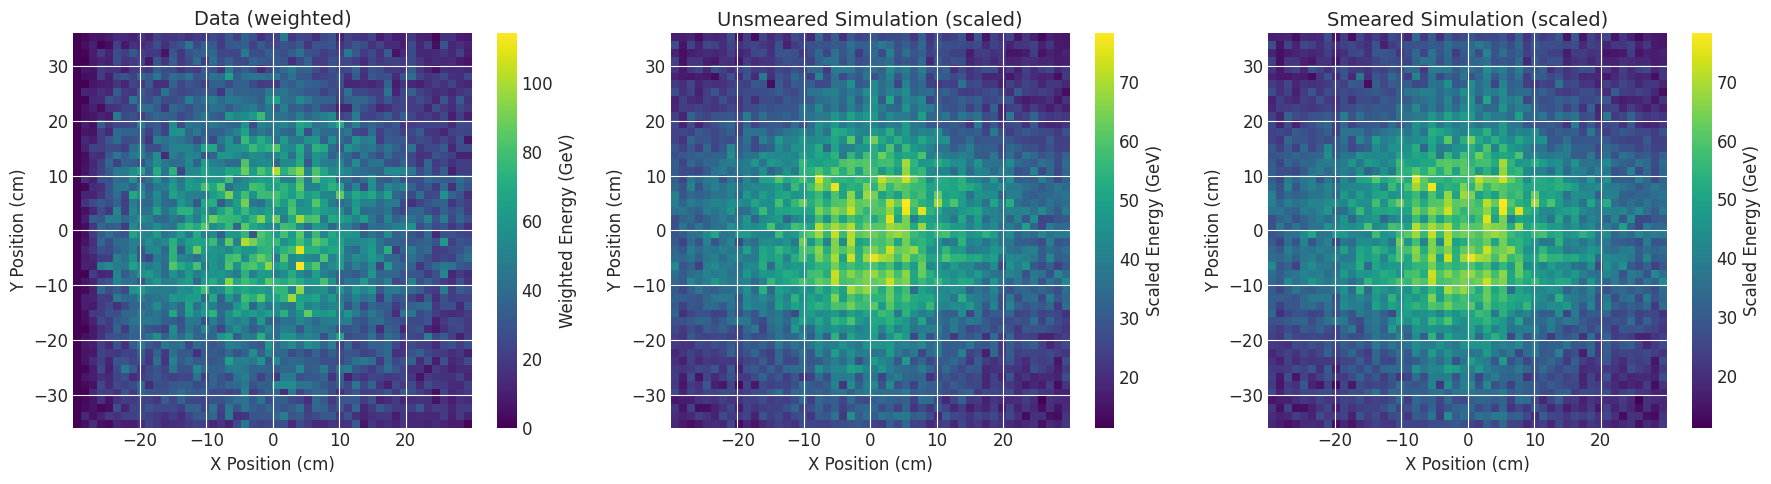


Cluster Energy Distribution Summary:
Data total weighted energy: 89622.17 GeV
Unsmeared sim total energy: 511262.81 GeV (scaled by 0.1753)
Smeared sim total energy: 523874.22 GeV (scaled by 0.1711)

Data clusters: 1601004 (from 800502 events, 2 photons each)
Unsmeared sim clusters: 226846 (from 113423 events)
Smeared sim clusters: 226846 (from 113423 events)


In [149]:
# Visualize cluster energy distribution over the calorimeter face
# This shows how smearing affects the energy distribution

# For data: use both photon clusters, weight with pi0_weight * is_exclusive
# For simulation: use all clusters from clust_X, clust_Y, clust_E arrays, unsmeared uses mmiss != -999 cut

# Data: combine both photon clusters
data_clust_x = np.concatenate([data['cluster_x_1'][data_cut], data['cluster_x_2'][data_cut]])
data_clust_y = np.concatenate([data['cluster_y_1'][data_cut], data['cluster_y_2'][data_cut]])
data_clust_e = np.concatenate([data['cluster_e_1'][data_cut], data['cluster_e_2'][data_cut]])
# Duplicate weights for both clusters
data_weights_clust = data['weight'][data_cut] if len(data['weight']) > 0 else np.ones(np.sum(data_cut))
is_excl_clust = data['is_exclusive'][data_cut] if len(data['is_exclusive']) > 0 else np.ones(np.sum(data_cut))
data_clust_weights = np.concatenate([
    data_weights_clust * is_excl_clust,
    data_weights_clust * is_excl_clust
])

# Simulation unsmeared: apply mmiss != -999 cut, then flatten cluster arrays
sim_mmiss_cut = sim['mmiss'] != -999
# Flatten jagged arrays for clusters (each event can have multiple clusters)
import awkward as ak
sim_clust_x_jagged = sim['clust_X'][sim_mmiss_cut]
sim_clust_y_jagged = sim['clust_Y'][sim_mmiss_cut]
sim_clust_e_jagged = sim['clust_E'][sim_mmiss_cut]

# Flatten to get all clusters
sim_clust_x = ak.flatten(sim_clust_x_jagged).to_numpy()
sim_clust_y = ak.flatten(sim_clust_y_jagged).to_numpy()
sim_clust_e = ak.flatten(sim_clust_e_jagged).to_numpy()

# Simulation smeared: flatten cluster arrays for all events
sim_smeared_clust_x_jagged = sim_smeared['clust_X'][sim_smeared_cut]
sim_smeared_clust_y_jagged = sim_smeared['clust_Y'][sim_smeared_cut]
sim_smeared_clust_e_jagged = sim_smeared['clust_E'][sim_smeared_cut]

sim_smeared_clust_x = ak.flatten(sim_smeared_clust_x_jagged).to_numpy()
sim_smeared_clust_y = ak.flatten(sim_smeared_clust_y_jagged).to_numpy()
sim_smeared_clust_e = ak.flatten(sim_smeared_clust_e_jagged).to_numpy()

# Create 2D histograms for energy distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define bins for calorimeter face
x_bins = 50
y_bins = 50

# Data
h_data, xedges, yedges = np.histogram2d(
    data_clust_x, data_clust_y, bins=[x_bins, y_bins],
    weights=data_clust_e * data_clust_weights
)
im1 = axes[0].imshow(h_data.T, origin='lower', aspect='auto',
                     extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                     cmap='viridis', interpolation='nearest')
axes[0].set_title('Data (weighted)', fontsize=14)
axes[0].set_xlabel('X Position (cm)', fontsize=12)
axes[0].set_ylabel('Y Position (cm)', fontsize=12)
plt.colorbar(im1, ax=axes[0], label='Weighted Energy (GeV)')

# Unsmeared simulation - scale to match data total
data_total_energy = np.sum(data_clust_e * data_clust_weights)
h_sim, _, _ = np.histogram2d(
    sim_clust_x, sim_clust_y, bins=[x_bins, y_bins],
    weights=sim_clust_e
)
sim_total_energy = np.sum(sim_clust_e)
scale_factor = data_total_energy / sim_total_energy if sim_total_energy > 0 else 1.0
h_sim_scaled = h_sim * scale_factor

im2 = axes[1].imshow(h_sim_scaled.T, origin='lower', aspect='auto',
                     extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                     cmap='viridis', interpolation='nearest')
axes[1].set_title('Unsmeared Simulation (scaled)', fontsize=14)
axes[1].set_xlabel('X Position (cm)', fontsize=12)
axes[1].set_ylabel('Y Position (cm)', fontsize=12)
plt.colorbar(im2, ax=axes[1], label='Scaled Energy (GeV)')

# Smeared simulation - scale to match data total
h_sim_smeared, _, _ = np.histogram2d(
    sim_smeared_clust_x, sim_smeared_clust_y, bins=[x_bins, y_bins],
    weights=sim_smeared_clust_e
)
sim_smeared_total_energy = np.sum(sim_smeared_clust_e)
scale_factor_smeared = data_total_energy / sim_smeared_total_energy if sim_smeared_total_energy > 0 else 1.0
h_sim_smeared_scaled = h_sim_smeared * scale_factor_smeared

im3 = axes[2].imshow(h_sim_smeared_scaled.T, origin='lower', aspect='auto',
                     extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                     cmap='viridis', interpolation='nearest')
axes[2].set_title('Smeared Simulation (scaled)', fontsize=14)
axes[2].set_xlabel('X Position (cm)', fontsize=12)
axes[2].set_ylabel('Y Position (cm)', fontsize=12)
plt.colorbar(im3, ax=axes[2], label='Scaled Energy (GeV)')

plt.tight_layout()
plt.show()

print("\nCluster Energy Distribution Summary:")
print(f"Data total weighted energy: {data_total_energy:.2f} GeV")
print(f"Unsmeared sim total energy: {sim_total_energy:.2f} GeV (scaled by {scale_factor:.4f})")
print(f"Smeared sim total energy: {sim_smeared_total_energy:.2f} GeV (scaled by {scale_factor_smeared:.4f})")
print(f"\nData clusters: {len(data_clust_x)} (from {np.sum(data_cut)} events, 2 photons each)")
print(f"Unsmeared sim clusters: {len(sim_clust_x)} (from {np.sum(sim_mmiss_cut)} events)")
print(f"Smeared sim clusters: {len(sim_smeared_clust_x)} (from {np.sum(sim_smeared_cut)} events)")

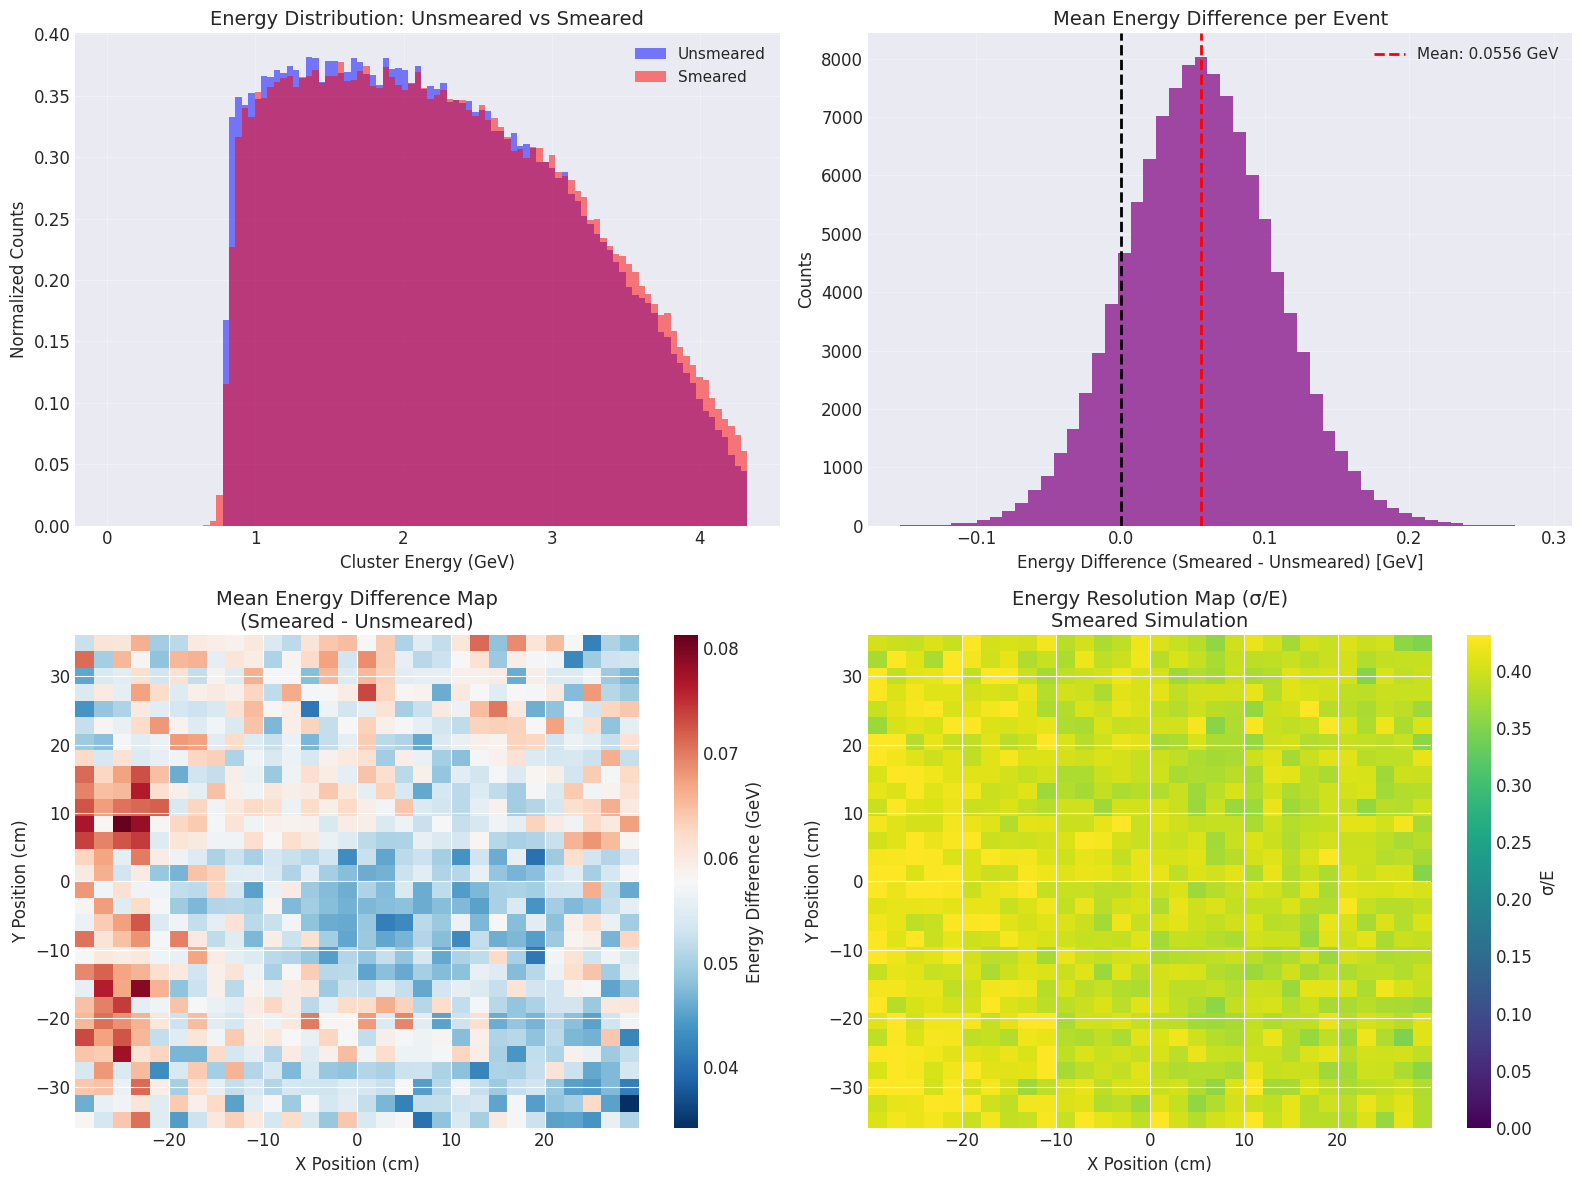


=== Energy Distribution Comparison ===
Unsmeared simulation:
  Mean cluster energy: 2.2538 GeV
  Std cluster energy: 0.9026 GeV
  Energy resolution (σ/E): 0.4005

Smeared simulation:
  Mean cluster energy: 2.3094 GeV
  Std cluster energy: 0.9275 GeV
  Energy resolution (σ/E): 0.4016

Mean event-level energy difference: 0.0556 ± 0.0511 GeV
RMS energy difference: 0.0755 GeV


In [150]:
# Compare unsmeared vs smeared energy distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Energy histogram comparison
ax1 = axes[0, 0]
bins_e = 100
range_e = (0, np.percentile(np.concatenate([sim_clust_e, sim_smeared_clust_e]), 99))

ax1.hist(sim_clust_e, bins=bins_e, range=range_e, alpha=0.5, 
         label='Unsmeared', color='blue', density=True)
ax1.hist(sim_smeared_clust_e, bins=bins_e, range=range_e, alpha=0.5,
         label='Smeared', color='red', density=True)
ax1.set_xlabel('Cluster Energy (GeV)', fontsize=12)
ax1.set_ylabel('Normalized Counts', fontsize=12)
ax1.set_title('Energy Distribution: Unsmeared vs Smeared', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 2. Energy difference histogram
ax2 = axes[0, 1]
# For this, we need to match clusters by event - using the mean energy per event
sim_mean_e = np.array([np.mean(e) if len(e) > 0 else 0 for e in sim_clust_e_jagged])
sim_smeared_mean_e = np.array([np.mean(e) if len(e) > 0 else 0 for e in sim_smeared_clust_e_jagged])
energy_diff = sim_smeared_mean_e - sim_mean_e

ax2.hist(energy_diff, bins=50, color='purple', alpha=0.7)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=2)
ax2.axvline(x=np.mean(energy_diff), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {np.mean(energy_diff):.4f} GeV')
ax2.set_xlabel('Energy Difference (Smeared - Unsmeared) [GeV]', fontsize=12)
ax2.set_ylabel('Counts', fontsize=12)
ax2.set_title('Mean Energy Difference per Event', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# 3. Position-dependent energy difference (2D map)
ax3 = axes[1, 0]
# Calculate mean energies in position bins
x_bins = 30
y_bins = 30

h_unsm, xedges, yedges = np.histogram2d(sim_clust_x, sim_clust_y, bins=[x_bins, y_bins])
h_unsm_e, _, _ = np.histogram2d(sim_clust_x, sim_clust_y, bins=[x_bins, y_bins], weights=sim_clust_e)
mean_e_unsm = np.divide(h_unsm_e, h_unsm, out=np.zeros_like(h_unsm_e), where=h_unsm!=0)

h_sm, _, _ = np.histogram2d(sim_smeared_clust_x, sim_smeared_clust_y, bins=[x_bins, y_bins])
h_sm_e, _, _ = np.histogram2d(sim_smeared_clust_x, sim_smeared_clust_y, bins=[x_bins, y_bins], weights=sim_smeared_clust_e)
mean_e_sm = np.divide(h_sm_e, h_sm, out=np.zeros_like(h_sm_e), where=h_sm!=0)

diff_map = mean_e_sm - mean_e_unsm
im = ax3.imshow(diff_map.T, origin='lower', aspect='auto',
                extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                cmap='RdBu_r', interpolation='nearest')
ax3.set_xlabel('X Position (cm)', fontsize=12)
ax3.set_ylabel('Y Position (cm)', fontsize=12)
ax3.set_title('Mean Energy Difference Map\n(Smeared - Unsmeared)', fontsize=14)
plt.colorbar(im, ax=ax3, label='Energy Difference (GeV)')

# 4. Energy resolution as function of position
ax4 = axes[1, 1]
# Calculate resolution (std/mean) in position bins
resolution_map = np.zeros((x_bins, y_bins))
for i in range(x_bins):
    for j in range(y_bins):
        mask_unsm = ((sim_clust_x >= xedges[i]) & (sim_clust_x < xedges[i+1]) &
                     (sim_clust_y >= yedges[j]) & (sim_clust_y < yedges[j+1]))
        mask_sm = ((sim_smeared_clust_x >= xedges[i]) & (sim_smeared_clust_x < xedges[i+1]) &
                   (sim_smeared_clust_y >= yedges[j]) & (sim_smeared_clust_y < yedges[j+1]))
        
        if np.sum(mask_sm) > 10:  # Need sufficient statistics
            e_sm = sim_smeared_clust_e[mask_sm]
            mean_e = np.mean(e_sm)
            std_e = np.std(e_sm)
            if mean_e > 0:
                resolution_map[i, j] = std_e / mean_e
            else:
                resolution_map[i, j] = 0
        else:
            resolution_map[i, j] = 0

im2 = ax4.imshow(resolution_map.T, origin='lower', aspect='auto',
                 extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                 cmap='viridis', interpolation='nearest', vmin=0, vmax=np.percentile(resolution_map[resolution_map>0], 95))
ax4.set_xlabel('X Position (cm)', fontsize=12)
ax4.set_ylabel('Y Position (cm)', fontsize=12)
ax4.set_title('Energy Resolution Map (σ/E)\nSmeared Simulation', fontsize=14)
plt.colorbar(im2, ax=ax4, label='σ/E')

plt.tight_layout()
plt.show()

print("\n=== Energy Distribution Comparison ===")
print(f"Unsmeared simulation:")
print(f"  Mean cluster energy: {np.mean(sim_clust_e):.4f} GeV")
print(f"  Std cluster energy: {np.std(sim_clust_e):.4f} GeV")
print(f"  Energy resolution (σ/E): {np.std(sim_clust_e)/np.mean(sim_clust_e):.4f}")

print(f"\nSmeared simulation:")
print(f"  Mean cluster energy: {np.mean(sim_smeared_clust_e):.4f} GeV")
print(f"  Std cluster energy: {np.std(sim_smeared_clust_e):.4f} GeV")
print(f"  Energy resolution (σ/E): {np.std(sim_smeared_clust_e)/np.mean(sim_smeared_clust_e):.4f}")

print(f"\nMean event-level energy difference: {np.mean(energy_diff):.4f} ± {np.std(energy_diff):.4f} GeV")
print(f"RMS energy difference: {np.sqrt(np.mean(energy_diff**2)):.4f} GeV")

## Summary Statistics Table

In [151]:
# Create summary table
summary_vars = ['mpi0', 'mmiss', 'Q2', 'W', 'xB', 'z']
summary_data = []

for var in summary_vars:
    if var in data and var in sim and var in sim_smeared:
        data_vals = data[var][data_cut]
        sim_vals = sim[var][sim_cut]
        sim_smeared_vals = sim_smeared[var][sim_smeared_cut]
        
        # Filter sentinel values
        data_vals = data_vals[data_vals > -900]
        sim_vals = sim_vals[sim_vals > -900]
        sim_smeared_vals = sim_smeared_vals[sim_smeared_vals > -900]
        
        summary_data.append({
            'Variable': var,
            'Data Mean': f"{np.mean(data_vals):.4f}",
            'Data Std': f"{np.std(data_vals):.4f}",
            'Sim Mean': f"{np.mean(sim_vals):.4f}",
            'Sim Std': f"{np.std(sim_vals):.4f}",
            'Smeared Mean': f"{np.mean(sim_smeared_vals):.4f}",
            'Smeared Std': f"{np.std(sim_smeared_vals):.4f}"
        })

summary_df = pd.DataFrame(summary_data)
print("\n=== Summary Statistics ===")
print(summary_df.to_string(index=False))


=== Summary Statistics ===
Variable Data Mean Data Std Sim Mean Sim Std Smeared Mean Smeared Std
    mpi0    0.1140   0.0526   0.1287  0.0052       0.1318      0.0062
   mmiss    1.6265   0.3840   1.1051  0.1577       1.0588      0.1694
      Q2    5.7143   0.5703   6.0559  0.6378       6.0559      0.6378
       W    2.3674   0.2215   2.2572  0.2631       2.2572      0.2631
      xB    0.5483   0.0775   0.5905  0.0910       0.5905      0.0910
       z    0.5535   0.1903   0.8162  0.0928       0.8363      0.0968


## Chi-Square Goodness of Fit

In [152]:
def calculate_chi2(data_vals, sim_vals, bins, range_vals, data_weights=None, sim_weights=None):
    """
    Calculate chi-square goodness of fit between data and simulation
    Uses unweighted simulation (weight=1.0) to match chi2_scans.pdf methodology
    """
    data_counts, bin_edges = np.histogram(data_vals, bins=bins, range=range_vals, weights=data_weights)
    # Use unweighted simulation
    sim_counts_unweighted, _ = np.histogram(sim_vals, bins=bin_edges, weights=None)
    
    # Scale simulation to match data integral
    data_integral = np.sum(data_counts)
    sim_integral = np.sum(sim_counts_unweighted)
    if sim_integral > 0:
        sim_counts = sim_counts_unweighted * (data_integral / sim_integral)
    else:
        sim_counts = sim_counts_unweighted
    
    # Only consider bins with data
    mask = data_counts > 0
    
    # Chi-square calculation
    chi2 = np.sum((data_counts[mask] - sim_counts[mask])**2 / data_counts[mask])
    ndf = np.sum(mask) - 1  # degrees of freedom
    
    return chi2, ndf, chi2/ndf

# Calculate chi2 for key variables
print("\n=== Chi-Square Goodness of Fit ===")
print("Note: Using unweighted simulation (weight=1.0 per event) to match chi2_scans.pdf methodology")
print("Note: All variables except mpi0 use pi0_weight * is_exclusive for data")
print("\nVariable\t\tχ²\t\tNDF\tχ²/NDF (Unsmeared)\tχ²/NDF (Smeared)")
print("-" * 90)

test_vars = [
    ('mpi0', 60, (0.0, 0.3)),
    ('mmiss', 60, (0.7, 1.2)),
    ('Q2', 50, (0, 10)),
    ('W', 50, (1.5, 4.0)),
    ('xB', 50, (0.0, 1.0)),
    ('z', 50, (0.0, 1.5))
]

for var, bins, range_vals in test_vars:
    if var in data and var in sim and var in sim_smeared:
        data_vals = data[var][data_cut]
        sim_vals = sim[var][sim_cut]
        sim_smeared_vals = sim_smeared[var][sim_smeared_cut]
        
        # Apply appropriate weights for data
        if var == 'mpi0':
            # mpi0 uses only pi0_weight
            data_weights_chi2 = data['weight'][data_cut] if len(data['weight']) > 0 else None
        else:
            # All other variables use pi0_weight * is_exclusive
            base_weight = data['weight'][data_cut] if len(data['weight']) > 0 else np.ones(np.sum(data_cut))
            is_excl = data['is_exclusive'][data_cut] if len(data['is_exclusive']) > 0 else np.ones(np.sum(data_cut))
            data_weights_chi2 = base_weight * is_excl
        
        chi2_unsm, ndf_unsm, chi2ndf_unsm = calculate_chi2(data_vals, sim_vals, bins, range_vals, data_weights_chi2, None)
        chi2_sm, ndf_sm, chi2ndf_sm = calculate_chi2(data_vals, sim_smeared_vals, bins, range_vals, data_weights_chi2, None)
        
        print(f"{var:15s}\t{chi2_unsm:8.2f}\t{ndf_unsm:4d}\t{chi2ndf_unsm:8.3f}\t\t{chi2ndf_sm:8.3f}")



=== Chi-Square Goodness of Fit ===
Note: Using unweighted simulation (weight=1.0 per event) to match chi2_scans.pdf methodology
Note: All variables except mpi0 use pi0_weight * is_exclusive for data

Variable		χ²		NDF	χ²/NDF (Unsmeared)	χ²/NDF (Smeared)
------------------------------------------------------------------------------------------


mpi0           	50593.71	  57	 887.609		 320.681
mmiss          	22700.37	  59	 384.752		  45.746
Q2             	 2210.71	  17	 130.042		 130.042
W              	  829.01	  24	  34.542		  34.542
xB             	 1380.95	  24	  57.540		  57.540
z              	13452.27	  37	 363.575		 149.740
